# Mô hình ResNet50

# CELL 1: Thiết lập & Chuẩn bị dữ liệu

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import random
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, cohen_kappa_score
from sklearn.model_selection import train_test_split
from collections import Counter
import plotly.express as px
import warnings
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
warnings.filterwarnings("ignore")
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

# CELL 2: Cấu hình MySQL + Tạo Labels

In [3]:
db_config = {
    "host": "localhost",        # đổi thành host MySQL của bạn
    "user": "root",             # username MySQL
    "password": "Namkhanh210@", # password MySQL
    "database": "diabetic_retinopathy"
}

# --- Kết nối MySQL ---
conn = mysql.connector.connect(**db_config)
cursor = conn.cursor()

# --- Tạo bảng nếu chưa tồn tại ---
cursor.execute("""
CREATE TABLE IF NOT EXISTS diabetic_retinopathy (
    id INT AUTO_INCREMENT PRIMARY KEY,
    image_path VARCHAR(255) NOT NULL,
    label VARCHAR(50) NOT NULL
)
""")
conn.commit()

# --- Thư mục gốc chứa nhiều thư mục con ---
root_folder = r"data"

# --- Duyệt toàn bộ thư mục con ---
for subdir, dirs, files in os.walk(root_folder):
    label = os.path.basename(subdir)  # tên thư mục con làm label
    for file_name in files:
        # Lưu đường dẫn tuyệt đối
        absolute_path = os.path.abspath(os.path.join(subdir, file_name))
        cursor.execute(
            "INSERT INTO diabetic_retinopathy (image_path, label) VALUES (%s, %s)",
            (absolute_path, label)
        )
    

conn.commit()
cursor.close()
conn.close()

print("Đã chèn xong tất cả ảnh vào bảng diabetic_retinopathy.")
# ĐƯỜNG DẪN CỦA BẠN
BASE_DIR = r"C:\Users\Admin\.vscode\ResNet50\diabetic-retinopathy"
CSV_PATH = os.path.join(BASE_DIR, "labels.csv")
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "resnet50_dr_PRO.pth")
# Tự động tạo labels.csv nếu chưa có
if not os.path.exists(CSV_PATH):
    print("Đang tạo file labels.csv từ 5 thư mục...")
    data = []
    folders = {"Healthy":0, "Mild DR":1, "Moderate DR":2, "Proliferate DR":3, "Severe DR":4}
    for folder, label in folders.items():
        path = os.path.join(BASE_DIR, folder)
        for f in os.listdir(path):
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                data.append([f, label])
    pd.DataFrame(data, columns=['image_id','level']).to_csv(CSV_PATH, index=False)
    print(f"Đã tạo xong {len(data)} ảnh → {CSV_PATH}")
else:
    df_temp = pd.read_csv(CSV_PATH)
    print(f"Đã tìm thấy file CSV: {len(df_temp)} ảnh")

Đã chèn xong tất cả ảnh vào bảng diabetic_retinopathy.
Đã tìm thấy file CSV: 1986 ảnh


# Phân Bố Dữ Liệu Võng Mạc Tiểu Đường

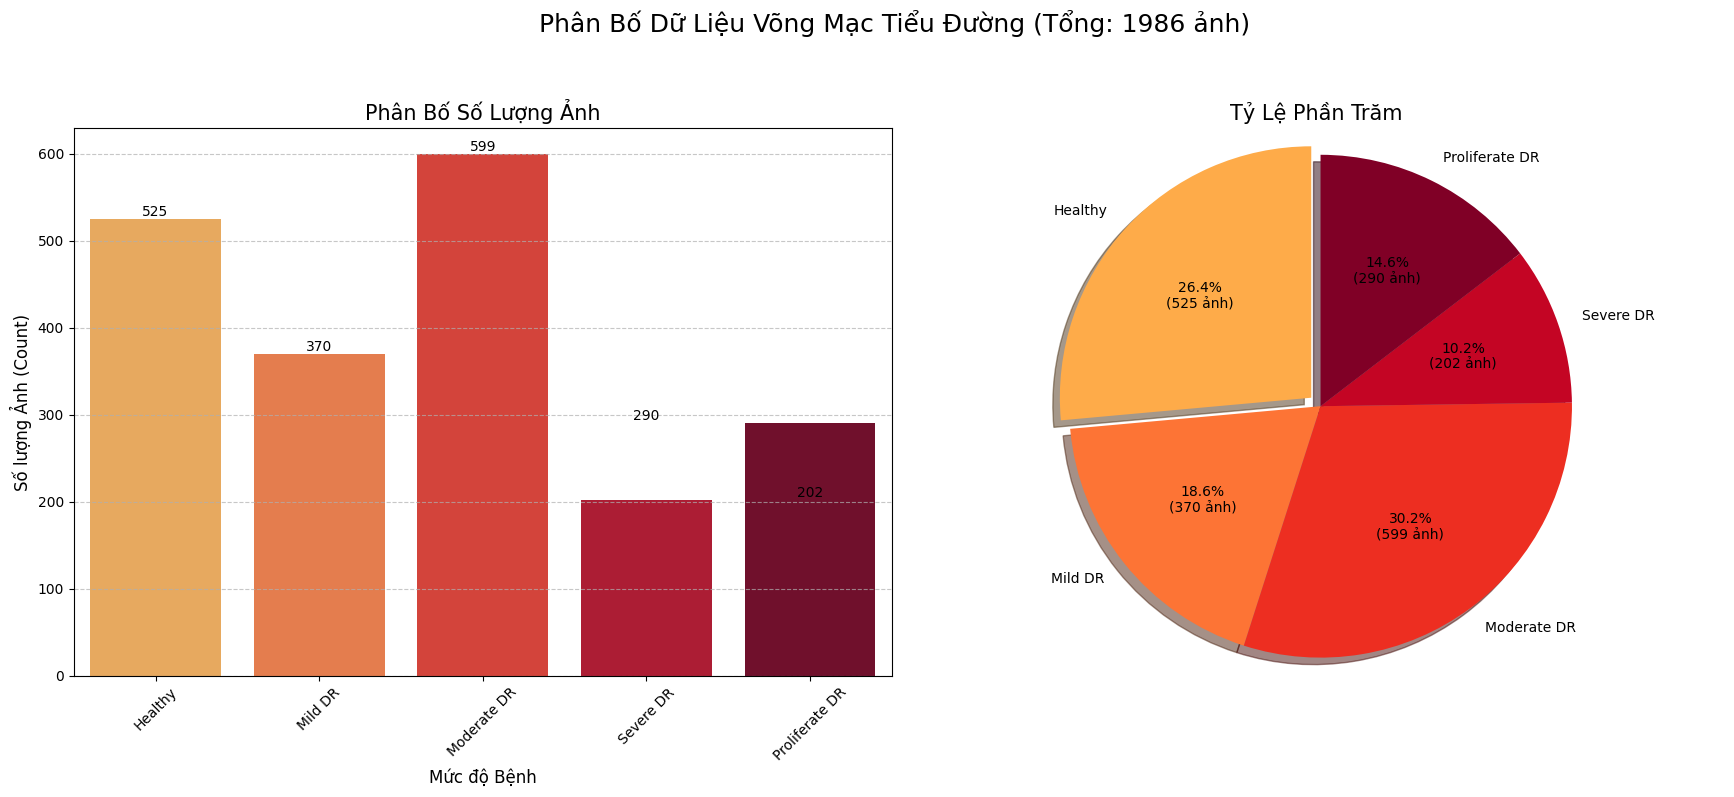

In [4]:

BASE_DIR = r"C:\Users\Admin\.vscode\ResNet50\diabetic-retinopathy" 
folders = ["Healthy", "Mild DR", "Moderate DR", "Proliferate DR", "Severe DR"]

# --- 1. Thu thập và Xử lý dữ liệu ---
class_counts = {}
for folder in folders:
    folder_path = os.path.join(BASE_DIR, folder)
    if os.path.exists(folder_path):
        img_files = [f for f in os.listdir(folder_path) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[folder] = len(img_files)
    else:
        print(f"Cảnh báo: Không tìm thấy thư mục {folder_path}")

data_df = pd.DataFrame(list(class_counts.items()), columns=['Mức độ Bệnh', 'Số lượng Ảnh'])
total_samples = data_df['Số lượng Ảnh'].sum()
data_df = data_df[data_df['Số lượng Ảnh'] > 0].reset_index(drop=True)

# Sắp xếp thứ tự các lớp
order = ["Healthy", "Mild DR", "Moderate DR", "Severe DR", "Proliferate DR"]
data_df['Mức độ Bệnh'] = pd.Categorical(data_df['Mức độ Bệnh'], categories=order, ordered=True)
data_df = data_df.sort_values('Mức độ Bệnh')

# Dữ liệu cho biểu đồ
sizes = data_df['Số lượng Ảnh']
labels = data_df['Mức độ Bệnh']

# Định nghĩa Gam màu nóng (YlOrRd) cho cả hai biểu đồ
cmap = plt.cm.get_cmap('YlOrRd') 
colors = [cmap(i) for i in np.linspace(0.4, 1, len(sizes))] 

# --- 2. Tạo Figure và Subplots ---
# Tạo một hình vẽ (figure) với 2 cột biểu đồ (axes)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plt.suptitle(
    f'Phân Bố Dữ Liệu Võng Mạc Tiểu Đường (Tổng: {total_samples} ảnh)', 
    fontsize=18, 
    y=1.02 # Đặt tiêu đề cao hơn một chút
)

# --- Subplot 1: Biểu đồ Cột (Bar Plot) - Thể hiện Số lượng ---
ax1 = axes[0]
sns.barplot(
    x='Mức độ Bệnh', 
    y='Số lượng Ảnh', 
    data=data_df, 
    order=order, 
    palette=colors,
    ax=ax1
)
ax1.set_title('Phân Bố Số Lượng Ảnh', fontsize=15)
ax1.set_xlabel('Mức độ Bệnh', fontsize=12)
ax1.set_ylabel('Số lượng Ảnh (Count)', fontsize=12)
ax1.tick_params(axis='x', rotation=45) 
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm giá trị số lượng lên trên mỗi cột
for index, row in data_df.iterrows():
    ax1.text(index, row['Số lượng Ảnh'], str(row['Số lượng Ảnh']), 
             color='black', ha="center", va="bottom", fontsize=10)


# --- Subplot 2: Biểu đồ Hình Tròn (Pie Chart) - Thể hiện Tỷ lệ (%) ---
ax2 = axes[1]

# Hàm định dạng nhãn cho Pie Chart: hiển thị Tỷ lệ (%) và Số lượng
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val} ảnh)'
    return my_format

ax2.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct=autopct_format(sizes), 
    shadow=True, 
    startangle=90,
    explode=(0.05, 0, 0, 0, 0)[:len(sizes)]
)

ax2.set_title('Tỷ Lệ Phần Trăm', fontsize=15)
ax2.axis('equal') # Đảm bảo biểu đồ là hình tròn


# --- 3. Hiển thị ---
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Điều chỉnh bố cục tổng thể
plt.show()

# CELL 3: Chia dữ liệu chuẩn (Stratified) + Tính trọng số lớp

In [5]:
df = pd.read_csv(CSV_PATH)

# Chia train/val theo tỷ lệ lớp
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['level'], random_state=42
)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")
print("Phân bố val set:", val_df['level'].value_counts().sort_index().values)

# Tính class weights để xử lý mất cân bằng
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
counts = Counter(train_df['level'])
class_weights = torch.tensor([len(train_df)/(5 * counts.get(i, 1)) for i in range(5)], dtype=torch.float).to(device)
print("Class weights:", class_weights.cpu().numpy().round(3))

Train: 1588 | Val: 398
Phân bố val set: [105  74 120  58  41]
Class weights: [0.756 1.073 0.663 1.369 1.973]


# CELL 4: Data Augmentation & DataLoader

In [6]:

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class DRDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image_id']
        label = row['level']
        
        # Tìm ảnh trong đúng thư mục
        for folder in ["Healthy", "Mild DR", "Moderate DR", "Proliferate DR", "Severe DR"]:
            img_path = os.path.join(self.root_dir, folder, img_name)
            if os.path.exists(img_path):
                image = Image.open(img_path).convert('RGB')
                break
        
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)

# Tạo dataset và dataloader
train_dataset = DRDataset(train_df, BASE_DIR, train_transform)
val_dataset = DRDataset(val_df, BASE_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print("Dataset và DataLoader đã sẵn sàng!")

Dataset và DataLoader đã sẵn sàng!


# CELL 5: Xây dựng model ResNet50

In [7]:

def build_resnet50_dr(num_classes=5):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    # Freeze toàn bộ backbone
    for param in model.parameters():
        param.requires_grad = False
    
    # Thay lớp fully connected
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model.to(device)

model = build_resnet50_dr()
print("Model ResNet50 đã sẵn sàng!")

Model ResNet50 đã sẵn sàng!


# CELL 6: Huấn luyện với Kappa, Early Stopping, Scheduler

In [8]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)
best_kappa = -1.0
patience_count = 0
max_patience = 10

if os.path.exists(MODEL_SAVE_PATH):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    print("Đã tải model tốt nhất từ trước!")
else:
    print("Bắt đầu huấn luyện model PRO...")

    # ===== progress bar cho EPOCH =====
    epoch_bar = tqdm(range(1, 16), desc="Epoch Progress", dynamic_ncols=True)

    for epoch in epoch_bar:

        # ------------------------------
        # TRAIN LOOP
        # ------------------------------
        model.train()
        train_bar = tqdm(train_loader,
                         desc=f"Train {epoch}",
                         leave=False,
                         dynamic_ncols=True,
                         mininterval=0.05)

        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_bar.set_postfix(loss=loss.item())

        # ------------------------------
        # VALIDATION LOOP
        # ------------------------------
        model.eval()
        all_preds, all_labels = [], []

        val_bar = tqdm(val_loader,
                       desc=f"Val {epoch}",
                       leave=False,
                       dynamic_ncols=True,
                       mininterval=0.05)

        with torch.no_grad():
            for inputs, labels in val_bar:
                outputs = model(inputs.to(device))
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

        # cập nhật info lên thanh Epoch
        epoch_bar.set_postfix({
            "Acc": f"{acc:.4f}",
            "Kappa": f"{kappa:.4f}"
        })

        # ------------------------------
        # SAVE BEST MODEL
        # ------------------------------
        if kappa > best_kappa:
            best_kappa = kappa
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= max_patience:
                print("\nEarly stopping! Dừng huấn luyện.")
                break
        
        scheduler.step(kappa)

    print(f"\nHOÀN TẤT! Model tốt nhất lưu tại:\n{MODEL_SAVE_PATH}")

Đã tải model tốt nhất từ trước!


# CELL 7: Đánh giá cuối cùng

In [ ]:


model.eval()
all_preds, all_labels, all_prob = [], [], []

with torch.no_grad():
    for inputs, labels in val_loader:           # Duyệt val set
        outputs = model(inputs.to(device))      # Forward
        probs = torch.softmax(outputs, dim=1)   # Xác suất
        _, preds = torch.max(outputs, 1)        # Lớp dự đoán
        
        all_prob.extend(probs.cpu().numpy())    # Xác suất
        all_preds.extend(preds.cpu().numpy())   # Dự đoán
        all_labels.extend(labels.numpy())       # Nhãn thật

# Chuyển list → numpy
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_prob   = np.array(all_prob)

# Tính các chỉ số chính
acc   = accuracy_score(all_labels, all_preds)           # Độ chính xác
kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')  # Kappa
cm    = confusion_matrix(all_labels, all_preds)        # Ma trận nhầm lẫn

# In kết quả
print(f"Accuracy        : {acc:.4f}")
print(f"Quadratic Kappa : {kappa:.4f} ← chỉ số chính thức")


Accuracy        : 0.6080
Quadratic Kappa : 0.7339 ← chỉ số chính thức


In [10]:
if 'pred_prob' not in locals():
    model.eval()
    pred_prob = []
    with torch.no_grad():
        for inputs, _ in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            prob = torch.softmax(outputs, dim=1).cpu().numpy()
            pred_prob.extend(prob)
    pred_prob = np.array(pred_prob)

level_names = ['Khỏe (0)', 'Nhẹ (1)', 'Trung bình (2)', 'Nặng (3)', 'Tăng sinh (4)']

#  ===== BÁO CÁO HIỆU SUẤT MÔ HÌNH =====

# 1. Ma trận nhầm lẫn (số lượng tuyệt đối)

In [11]:

fig1 = px.imshow(cm, text_auto=True, aspect="auto",
                 x=level_names, y=level_names,
                 labels=dict(x="Dự đoán", y="Thực tế", color="Số lượng"),
                 title="1. Ma trận nhầm lẫn (Confusion Matrix)",
                 color_continuous_scale="Blues")
fig1.update_xaxes(side="top")
fig1.update_layout(height=550, title_x=0.5, font=dict(size=12))
fig1.show()
print("Ma trận nhầm lẫn (số lượng):\n", cm)

Ma trận nhầm lẫn (số lượng):
 [[100   1   3   1   0]
 [  6  32  27   4   5]
 [  8  10  73  13  16]
 [  0   4  32  13   9]
 [  1   2   9   5  24]]


# 2. Ma trận nhầm lẫn theo %

In [12]:

cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)  # tránh chia 0
fig2 = px.imshow(cm_norm*100, text_auto=True, aspect="auto",
                 x=level_names, y=level_names, zmin=0, zmax=100,
                 labels=dict(color="Tỷ lệ (%)"),
                 title="2. Ma trận nhầm lẫn theo tỷ lệ phần trăm (%)",
                 color_continuous_scale="Reds")
fig2.update_xaxes(side="top")
fig2.update_layout(height=550, title_x=0.5)
fig2.show()
print("Ma trận nhầm lẫn theo %:\n", np.round(cm_norm*100, 2))

Ma trận nhầm lẫn theo %:
 [[95.24  0.95  2.86  0.95  0.  ]
 [ 8.11 43.24 36.49  5.41  6.76]
 [ 6.67  8.33 60.83 10.83 13.33]
 [ 0.    6.9  55.17 22.41 15.52]
 [ 2.44  4.88 21.95 12.2  58.54]]


# 3. Precision, Recall, F1-score từng lớp

In [13]:

report = classification_report(all_labels, all_preds, target_names=level_names, output_dict=True, digits=4)
df_report = pd.DataFrame(report).T.round(4)
df_report = df_report.iloc[:5, :3]  # chỉ lấy 5 lớp, 3 chỉ số

fig3 = px.bar(df_report, barmode='group', text_auto='.4f',
              title="3. Precision, Recall, F1-score từng mức độ bệnh",
              labels={"value": "Điểm số", "variable": "Chỉ số"},
              color_discrete_sequence=px.colors.qualitative.Vivid)
fig3.update_layout(height=550, title_x=0.5, legend_title="")
fig3.show()
print("Bảng báo cáo chi tiết:\n", df_report)

Bảng báo cáo chi tiết:
                 precision  recall  f1-score
Khỏe (0)           0.8696  0.9524    0.9091
Nhẹ (1)            0.6531  0.4324    0.5203
Trung bình (2)     0.5069  0.6083    0.5530
Nặng (3)           0.3611  0.2241    0.2766
Tăng sinh (4)      0.4444  0.5854    0.5053


# Các công thức tính Precision, Recall và F1-score

In [ ]:
# Precision = TP / (TP + FP)
# Recall    = TP / (TP + FN)
# F1-score  = 2 × (Precision × Recall) / (Precision + Recall)

# 4. Tổng kết 2 đồng hồ đo hiệu suất

In [18]:

fig6 = go.Figure()

fig6.add_trace(go.Indicator(
    mode="gauge+number+delta",
    value=acc * 100,
    number={'suffix': "%", 'font': {'size': 48}},
    
    title={'text': "Accuracy", 'font': {'size': 24}},
    domain={'x': [0, 0.48], 'y': [0, 1]},
    gauge={'axis': {'range': [0, 100], 'tickwidth': 2},
           'bar': {'color': "#3366CC"},
           'steps': [{'range': [0, 70], 'color': "lightgray"},
                     {'range': [70, 85], 'color': "yellow"},
                     {'range': [85, 100], 'color': "lightgreen"}],
           'threshold': {'line': {'color': "red", 'width': 6}, 'thickness': 0.75, 'value': 90}}))

fig6.add_trace(go.Indicator(
    mode="gauge+number",
    value=kappa,
    number={'font': {'size': 48}},
    title={'text': "Quadratic Weighted Kappa", 'font': {'size': 20}},
    domain={'x': [0.52, 1], 'y': [0, 1]},
    gauge={'axis': {'range': [0, 1]},
           'bar': {'color': "#DC3912"},
           'steps': [{'range': [0, 0.6], 'color': "lightgray"},
                     {'range': [0.6, 0.8], 'color': "yellow"},
                     {'range': [0.8, 1], 'color': "lightgreen"}],
           'threshold': {'line': {'color': "red", 'width': 6}, 'thickness': 0.75, 'value': 0.85}}))

fig6.update_layout(title="<b>6. TỔNG KẾT HIỆU SUẤT MÔ HÌNH</b>",
                   title_x=0.5, height=550,
                   font=dict(size=14))
fig6.show()

print(f"Accuracy: {acc*100:.3f}%  |  Quadratic Weighted Kappa: {kappa:.4f}")

Accuracy: 60.804%  |  Quadratic Weighted Kappa: 0.7339


# Ảnh ngẫu nhiên từ Dataset

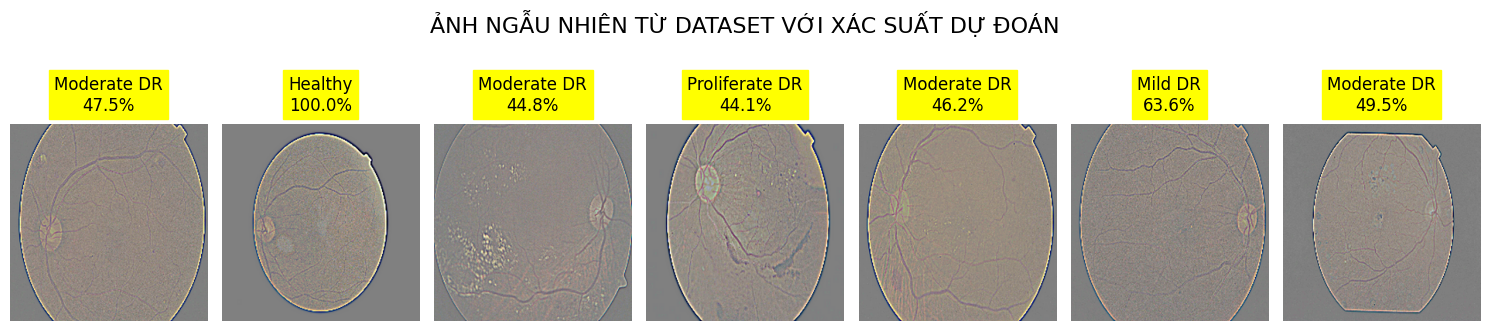

In [15]:
# --- Setup ---
BASE_DIR = r"C:\Users\Admin\.vscode\ResNet50\diabetic-retinopathy"
folders = ["Healthy", "Mild DR", "Moderate DR", "Proliferate DR", "Severe DR"]

# --- Transform ảnh để đưa vào model ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

plt.figure(figsize=(15, 4))

for i in range(7):
    folder = random.choice(folders)
    img_files = [f for f in os.listdir(os.path.join(BASE_DIR, folder)) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    img_file = random.choice(img_files)
    img_path = os.path.join(BASE_DIR, folder, img_file)
    img = Image.open(img_path).convert('RGB')
    
    # --- Chuẩn bị ảnh và dự đoán ---
    input_tensor = transform(img).unsqueeze(0).to(device)  # shape [1, 3, 224, 224]
    with torch.no_grad():
        output = model(input_tensor)          # logits
        probs = torch.softmax(output, dim=1)  # xác suất
        conf, pred_idx = torch.max(probs, dim=1)
        pred_label = folders[pred_idx.item()]
        conf_percent = conf.item() * 100
    
    # --- Hiển thị ảnh ---
    plt.subplot(1, 7, i+1)
    plt.imshow(img)
    plt.title(f"{pred_label}\n{conf_percent:.1f}%", fontsize=12, pad=10, 
              backgroundcolor='yellow', color='black')
    plt.axis('off')

plt.suptitle("ẢNH NGẪU NHIÊN TỪ DATASET VỚI XÁC SUẤT DỰ ĐOÁN", fontsize=16)
plt.tight_layout()
plt.show()
